<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Magnon_Orbital_Nernst_Effect_vs_SOT_Effects_Visualized_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

## Primer

The magnon orbital Nernst effect (abbreviated here as MONE) operates as a thermal linear response in which a temperature gradient drives a transverse current of magnon orbital angular momentum. Early theoretical frameworks predicted this response within kagome ferromagnets while arguing that the orbital angular momentum current can easily exceed the accompanying spin current (a characteristic that makes the phenomenon highly relevant for magnonic orbital torque concepts). Honeycomb antiferromagnet investigations later predicted MONE as an intrinsic response that can arise even without spin orbit coupling alongside proposed magnetoelectric readouts for direct electrical detection. Recent altermagnet calculations for ruthenium dioxide and chromium antimonide report a remarkably robust magnon orbital Nernst response tied to anisotropic exchange splitting while exhibiting reduced sensitivity to the Néel vector, the temperature gradient orientation, and the overarching magnetic domain structure.

Spin orbit torque (abbreviated SOT) represents an electrically driven angular momentum transfer mechanism in which a charge current generates a spin accumulation or spin current through fundamental channels such as the spin Hall effect, the Rashba Edelstein effect, the orbital Hall effect, thermal effects, and magnonic effects. The standard SOT roadmap reports commonly utilized damping like efficiencies near 0.10 for platinum, near −0.10 for tantalum, and near −0.33 for beta tungsten within representative thin film systems. Multidirectional SOT extends this established physical picture by using low symmetry materials or engineered symmetry breaking to generate multiple spin polarization components simultaneously. Recent empirical work utilizing the nickel tungsten alloy reports large SOT efficiency values of 0.3 in bulk samples and 0.73 in heterostructures (featuring distinct out of plane and Dresselhaus like components along with robust field free perpendicular switching).

## Glossary of Acronyms and Symbols

| Term or Symbol | Definition |
| --- | --- |
| Magnon orbital Nernst effect (MONE) | A thermal linear response generating a transverse orbital angular momentum current |
| Spin orbit torque (SOT) | An electrically driven angular momentum transfer mechanism |
| $B_{\mathrm{DL}}$ | Effective damping like magnetic flux density |
| $J$ | Charge current density |
| $M_s$ | Saturation magnetization |
| $t_F$ | Ferromagnet thickness |
| $\theta_{\mathrm{DL}}$ | Effective damping like spin orbit torque efficiency |
| $\nabla T$ | Temperature gradient |
| $\nabla_y T$ | Transverse temperature gradient component |
| $j_x^{L_z}$ | Transverse orbital current |
| $\alpha_{\mu\nu}^{L_\gamma}$ | Orbital Nernst conductivity |

## Phenomenological Comparison

| Aspect | Magnon orbital Nernst effect | Conventional SOT | Multidirectional SOT |
| --- | --- | --- | --- |
| Primary drive | Temperature gradient (usually $\nabla T$) | Charge current density ($J$) | Charge current density ($J$) |
| Transported angular momentum | Orbital angular momentum carried by charge neutral magnons | Spin angular momentum from a dominant spin polarization | Multiple spin polarization components from a spin Hall tensor or symmetry reduced interface |
| Symmetry lever | Berry curvature, scalar spin chirality, exchange geometry, altermagnetic exchange splitting | Spin Hall or Rashba Edelstein conversion in heavy metal or interface systems | Low crystal symmetry, low symmetry spin Hall tensor, structural asymmetry, interfacial conversion |
| Typical output | Transverse orbital current such as $j_x^{L_z}$ derived from $\nabla_y T$ | Damping like and field like torques with one main injected spin axis | Damping like and field like torques with in plane, out of plane, and Dresselhaus like channels |
| Energy path | Thermal magnon flow with reduced charge Joule heating | Electrical write path with Joule heating in the SOT layer | Electrical write path with stronger symmetry control and possible lower switching current |
| Strength metric | Orbital Nernst conductivity ($\alpha_{\mu\nu}^{L_\gamma}$) | Effective SOT efficiency ($\theta_{\mathrm{DL}}$), effective field, switching current | Tensor resolved $\theta_{\mathrm{DL}}$ components and vector switching efficiency |
| Device opportunity | Magnon orbitronics, thermal control, orbital torque transduction | MRAM, oscillators, domain wall motion, skyrmions | Field free switching, perpendicular magnet control, vector torque engineering |
| Main sensitivity | Gap, magnon lifetime, Berry curvature, thermal population, interface transduction | Spin Hall angle, resistivity, interface transparency, spin mixing conductance | Crystal orientation, tensor components, interface quality, current direction |

The comparative analysis plot utilizes a normalized response index because MONE and SOT couple to inherently different generalized forces. The SOT field plot employs the standard damping like estimate modeled by the equation

$$B_{\mathrm{DL}} = \frac{\hbar}{2e} \frac{\theta_{\mathrm{DL}} J}{M_s t_F}$$

where $B_{\mathrm{DL}}$ designates the effective magnetic flux density measured in tesla while $J$ represents the current density, $M_s$ signifies the saturation magnetization, and $t_F$ denotes the ferromagnet thickness. The MONE temperature curve relies upon a single gapped boson proxy combined with Bose occupation and a Hall type entropy weight (which functions as a qualitative model until material specific Berry curvature and magnon orbital moment data are explicitly inserted).

MONE serves as the thermal, magnonic, orbital angular momentum analogue of a transverse Hall type response, whereas conventional SOT functions as an electrical single axis spin torque mechanism, and multidirectional SOT operates as an electrical vector torque mechanism that gains advanced functionality from low symmetry spin generation. In the analytically plotted model, multidirectional SOT demonstrates the strongest current driven field because the selected nickel tungsten based efficiency substantially exceeds the conventional platinum like value, while MONE manifests as a temperature activated orbital channel whose practical torque value ultimately depends on successful orbital to spin or magnetoelectric transduction.

In [1]:
!python -m pip install -q uv
!uv pip install --system -q numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.8/24.8 MB 31.5 MB/s eta 0:00:00


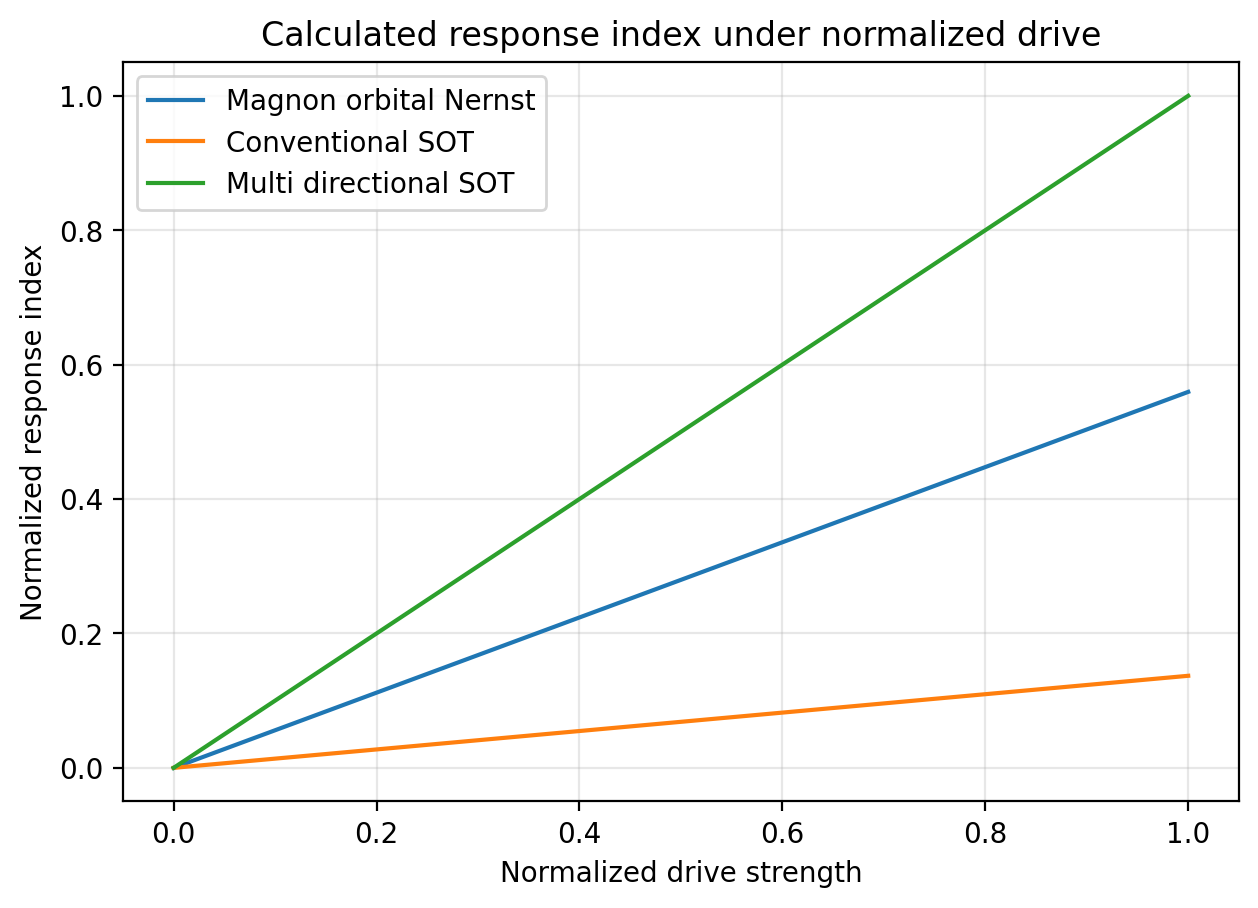

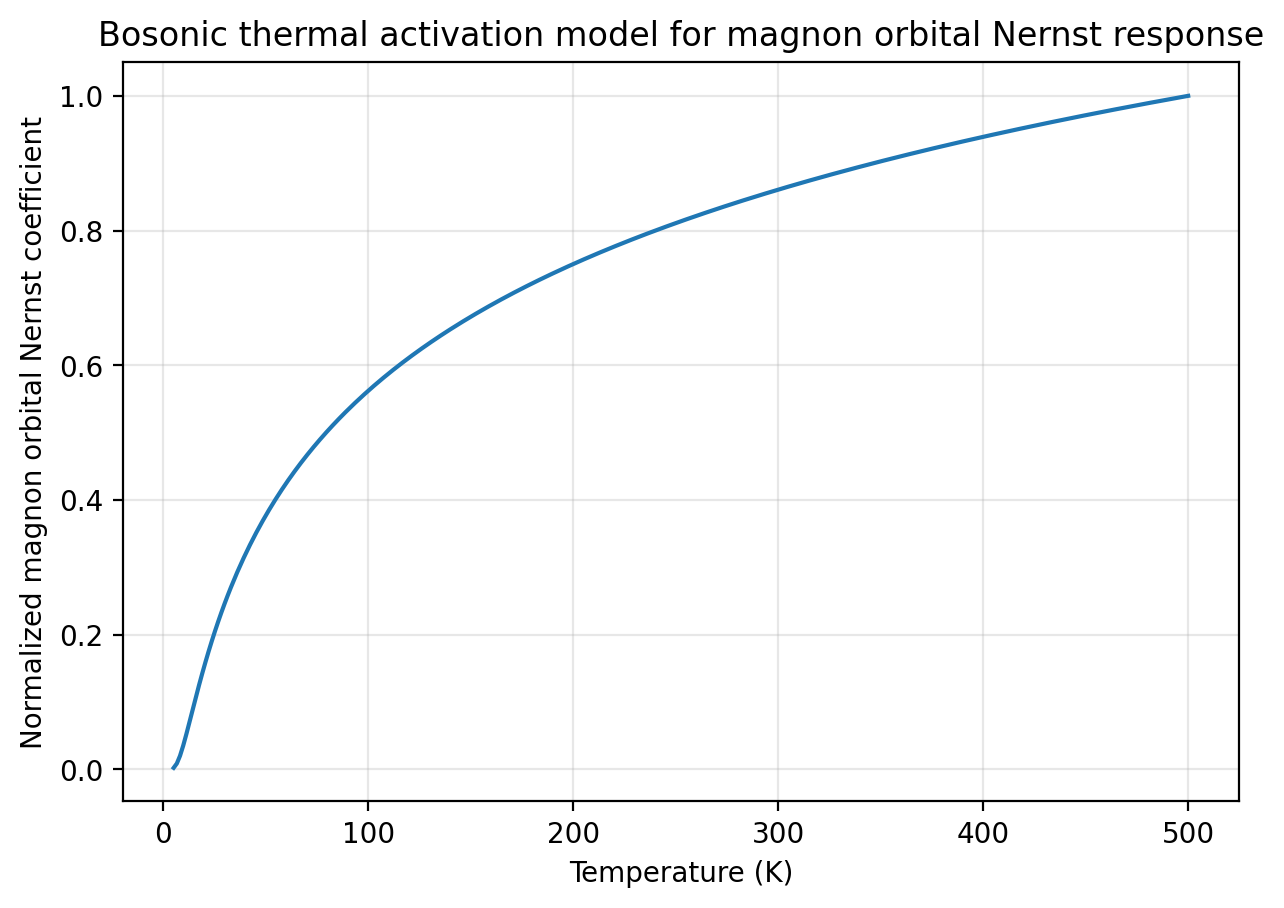

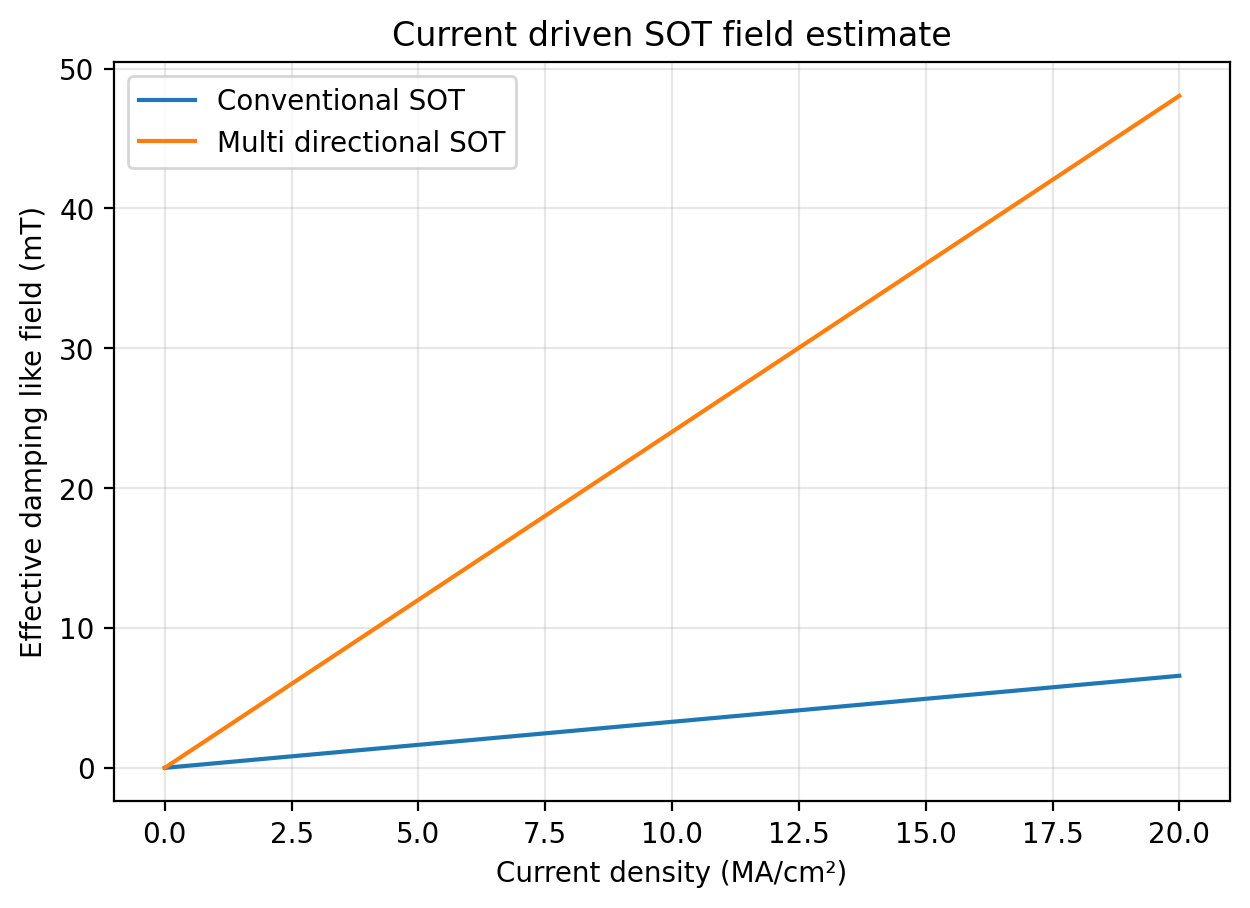

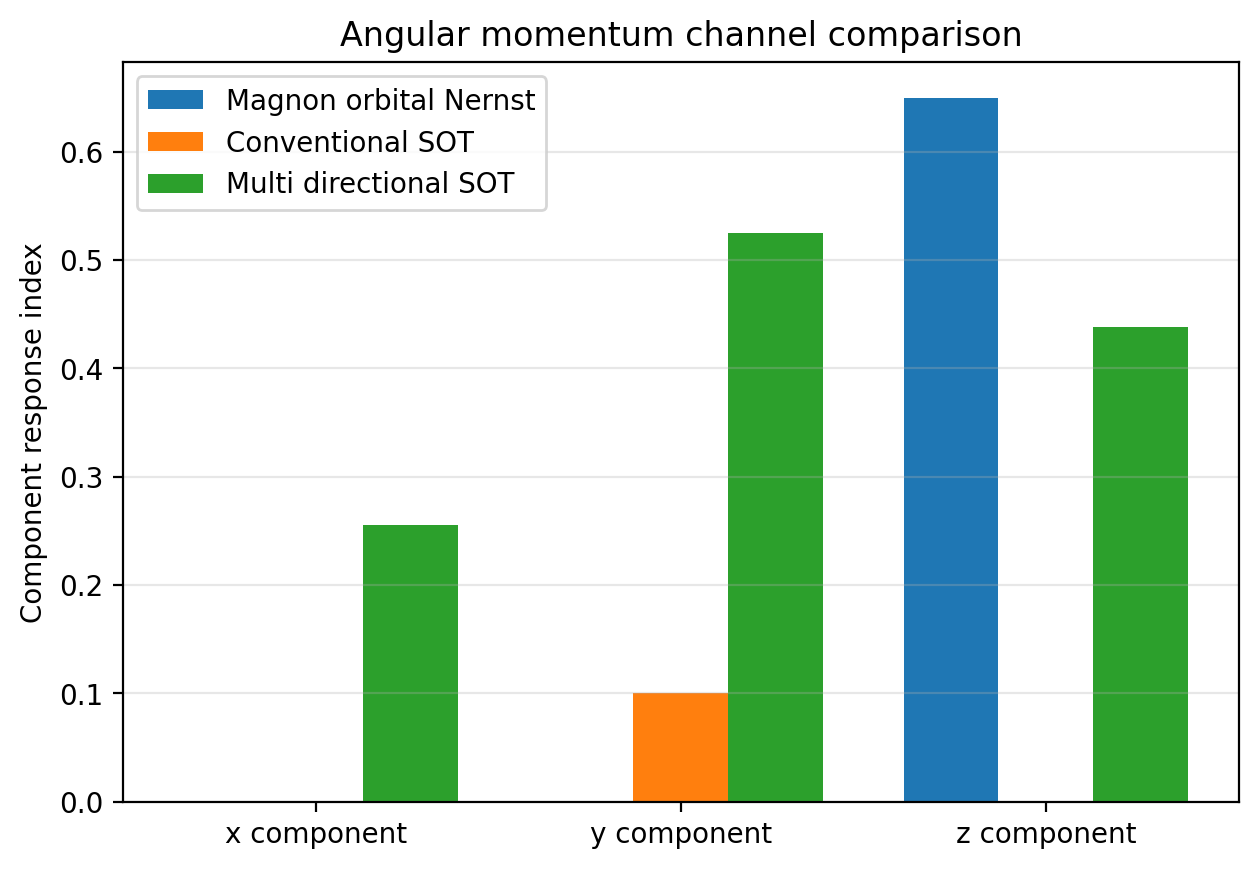

In [4]:
"""Calculated comparison of MONE, conventional SOT, and multi directional SOT."""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# CONTROL KNOBS
TEMPERATURE_K = 300.0
TEMPERATURE_MIN_K = 5.0
TEMPERATURE_MAX_K = 500.0
MAGNON_GAP_MEV = 3.0
MONE_BERRY_FACTOR = 1.0
MONE_ORBITAL_FACTOR = 1.0
MONE_INDEX_SCALE = 0.65
THERMAL_GRADIENT_MAX_K_PER_MM = 20.0

CURRENT_DENSITY_MAX_MA_PER_CM2 = 20.0
CURRENT_DENSITY_FOR_COMPONENTS_MA_PER_CM2 = 10.0
SATURATION_MAGNETIZATION_A_PER_M = 1.0e6
FERROMAGNET_THICKNESS_NM = 1.0

CONVENTIONAL_THETA_DL = 0.10
MULTIDIRECTIONAL_THETA_DL = 0.73
MULTIDIRECTIONAL_SPIN_VECTOR = np.array([0.35, 0.72, 0.60])

K_B_MEV_PER_K = 8.617333262e-2
HBAR_J_S = 1.054571817e-34
ELEMENTARY_CHARGE_C = 1.602176634e-19

mpl.rcParams["figure.dpi"] = 200


def bose_occupation(energy_mev, temperature_k):
    """Return Bose occupation for a bosonic mode."""
    temperature = np.asarray(temperature_k, dtype=float)
    x_value = energy_mev / (K_B_MEV_PER_K * temperature)
    x_value = np.clip(x_value, 1.0e-12, 700.0)
    return 1.0 / np.expm1(x_value)


def c1_boson_weight(occupation):
    """Return a bosonic entropy weight used in Hall type responses."""
    occupation = np.asarray(occupation, dtype=float)
    occupation = np.maximum(occupation, 1.0e-300)
    return ((1.0 + occupation) * np.log1p(occupation)
            - occupation * np.log(occupation))


def mone_coefficient(temperature_k):
    """Return a dimensionless magnon orbital Nernst coefficient."""
    occupation = bose_occupation(MAGNON_GAP_MEV, temperature_k)
    return (MONE_BERRY_FACTOR * MONE_ORBITAL_FACTOR
            * c1_boson_weight(occupation))


def effective_sot_field_mt(theta_eff, current_density_ma_cm2):
    """Return effective SOT field as millitesla."""
    current_density_a_m2 = current_density_ma_cm2 * 1.0e10
    thickness_m = FERROMAGNET_THICKNESS_NM * 1.0e-9
    field_t = ((HBAR_J_S / (2.0 * ELEMENTARY_CHARGE_C))
               * theta_eff
               * current_density_a_m2
               / (SATURATION_MAGNETIZATION_A_PER_M * thickness_m))
    return 1.0e3 * field_t


def unit_vector(vector):
    """Return a vector scaled to unit Euclidean length."""
    array = np.asarray(vector, dtype=float)
    magnitude = np.linalg.norm(array)
    if magnitude <= 0.0:
        raise ValueError("Vector magnitude must be positive.")
    return array / magnitude


drive = np.linspace(0.0, 1.0, 240)
temperature_grid = np.linspace(TEMPERATURE_MIN_K, TEMPERATURE_MAX_K, 320)
current_density = np.linspace(0.0, CURRENT_DENSITY_MAX_MA_PER_CM2, 240)

mone_at_temperature = mone_coefficient(TEMPERATURE_K)
mone_at_reference = mone_coefficient(TEMPERATURE_MAX_K)
mone_drive_index = (
    MONE_INDEX_SCALE * mone_at_temperature / mone_at_reference * drive
)
conventional_drive_index = (
    abs(CONVENTIONAL_THETA_DL) / abs(MULTIDIRECTIONAL_THETA_DL) * drive
)
multidirectional_drive_index = drive

plt.figure(figsize=(7.2, 4.8))
plt.plot(drive, mone_drive_index, label="Magnon orbital Nernst")
plt.plot(drive, conventional_drive_index, label="Conventional SOT")
plt.plot(drive, multidirectional_drive_index, label="Multi directional SOT")
plt.xlabel("Normalized drive strength")
plt.ylabel("Normalized response index")
plt.title("Calculated response index under normalized drive")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

mone_temperature_curve = mone_coefficient(temperature_grid)
mone_temperature_curve = mone_temperature_curve / np.max(mone_temperature_curve)

plt.figure(figsize=(7.2, 4.8))
plt.plot(temperature_grid, mone_temperature_curve)
plt.xlabel("Temperature (K)")
plt.ylabel("Normalized magnon orbital Nernst coefficient")
plt.title("Bosonic thermal activation model for magnon orbital Nernst response")
plt.grid(True, alpha=0.3)
plt.show()

conventional_field = effective_sot_field_mt(
    CONVENTIONAL_THETA_DL, current_density
)
multidirectional_field = effective_sot_field_mt(
    MULTIDIRECTIONAL_THETA_DL, current_density
)

plt.figure(figsize=(7.2, 4.8))
plt.plot(current_density, conventional_field, label="Conventional SOT")
plt.plot(current_density, multidirectional_field, label="Multi directional SOT")
plt.xlabel("Current density (MA/cm²)")
plt.ylabel("Effective damping like field (mT)")
plt.title("Current driven SOT field estimate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

component_labels = ["x component", "y component", "z component"]
positions = np.arange(len(component_labels))
bar_width = 0.26

conventional_components = (
    abs(CONVENTIONAL_THETA_DL) * np.array([0.0, 1.0, 0.0])
)
multidirectional_components = (
    abs(MULTIDIRECTIONAL_THETA_DL)
    * np.abs(unit_vector(MULTIDIRECTIONAL_SPIN_VECTOR))
)
mone_components = MONE_INDEX_SCALE * np.array([0.0, 0.0, 1.0])

plt.figure(figsize=(7.2, 4.8))
plt.bar(positions - bar_width, mone_components, bar_width,
        label="Magnon orbital Nernst")
plt.bar(positions, conventional_components, bar_width,
        label="Conventional SOT")
plt.bar(positions + bar_width, multidirectional_components, bar_width,
        label="Multi directional SOT")
plt.xticks(positions, component_labels)
plt.ylabel("Component response index")
plt.title("Angular momentum channel comparison")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.show()